<div style="background: linear-gradient(135deg, #1d361f 0%, #1f5f28 50%, #0f6037 100%); padding: 40px; border-radius: 12px; text-align: center; color: white; margin-bottom: 20px;">
  <h1 style="color: #e94560; font-size: 2.2em; margin-bottom: 10px;">🎓 Desafío 2 — Situación 3</h1>
  <h2 style="color: #ffffff; font-size: 1.4em;">Reducción de Dimensionalidad y Extracción de Características</h2>
  <h3 style="color: #a8dadc;">Clustering no supervisado de imágenes satelitales EuroSAT</h3>
  <hr style="border-color: #e94560; margin: 20px 0;">
  <p style="color: #ccc;"><b>Asignatura:</b> Análisis Multivariado</p>
  <p style="color: #ccc;"><b>Programa:</b> Maestría en Inteligencia Artificial y Ciencia de Datos</p>
  <p style="color: #ccc;"><b>Profesor:</b> Cristian E. García — Universidad Autónoma de Occidente</p>
  <p style="color: #ccc;"><b>Estudiantes:</b> Alejandro Meneses, Henry Rosenstiehl.</p>

</div>


# Desafío 2 — Situación 3

## Clustering no supervisado de imágenes satelitales EuroSAT

Este notebook desarrolla la Situación 3 del desafío, siguiendo el flujo general del problema: preparación de imágenes, reducción dimensional, modelado de clustering con K-Means y preparación para validación posterior.

La idea central es trabajar las imágenes como datos multivariados: cada imagen se convierte en un vector numérico, luego se reduce la dimensionalidad mediante PCA y finalmente se aplican modelos de clustering sobre el espacio reducido.

## 1. Librerías y configuración general

Se importan las librerías necesarias para manipulación de datos, carga de imágenes, reducción dimensional, clustering y visualización.

In [1]:
from pathlib import Path

import numpy as np
pandas_instalado = True
import pandas as pd

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


## 2. Carga del dataset y construcción del índice de imágenes

El dataset EuroSAT se encuentra organizado en carpetas, donde cada carpeta corresponde a una clase real de cobertura terrestre. Estas etiquetas se usarán solamente al final para validación externa, no durante el ajuste de los modelos de clustering.

Ajusta la variable `ruta_dataset` según la ubicación local del dataset en tu computador.

In [2]:
# Cambiar esta ruta por la ubicación del dataset
ruta_dataset = Path("EuroSAT_RGB")


def construir_indice_imagenes(ruta_dataset, extensiones=("*.jpg", "*.jpeg", "*.png")):
    """
    Construye un DataFrame con la ruta de cada imagen y su clase real,
    tomada del nombre de la carpeta contenedora.
    """
    registros = []

    for carpeta_clase in sorted(ruta_dataset.iterdir()):
        if carpeta_clase.is_dir():
            for extension in extensiones:
                for imagen in carpeta_clase.glob(extension):
                    registros.append({
                        "ruta": str(imagen),
                        "clase_real": carpeta_clase.name
                    })

    return pd.DataFrame(registros)


df_imagenes = construir_indice_imagenes(ruta_dataset)

print("Total de imágenes:", len(df_imagenes))
print("Número de clases:", df_imagenes["clase_real"].nunique())
display(df_imagenes["clase_real"].value_counts())
display(df_imagenes.head())

Total de imágenes: 27000
Número de clases: 10


clase_real
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
PermanentCrop           2500
Industrial              2500
River                   2500
Pasture                 2000
Name: count, dtype: int64

,ruta,clase_real
0,EuroSAT_RGB/AnnualCrop/AnnualCrop_157.jpg,AnnualCrop
1,EuroSAT_RGB/AnnualCrop/AnnualCrop_1948.jpg,AnnualCrop
2,EuroSAT_RGB/AnnualCrop/AnnualCrop_2607.jpg,AnnualCrop
3,EuroSAT_RGB/AnnualCrop/AnnualCrop_1905.jpg,AnnualCrop
4,EuroSAT_RGB/AnnualCrop/AnnualCrop_804.jpg,AnnualCrop


## 3. Preparación mínima de datos para clustering

Para aplicar PCA y clustering, cada imagen RGB se transforma en un vector numérico. Si las imágenes tienen tamaño 64×64 y tres canales, cada observación queda representada por 12.288 variables.

Este paso no introduce modelos adicionales: solo convierte las imágenes a una matriz numérica `X` apta para análisis multivariado.

In [3]:
def cargar_imagenes_como_matriz(df_imagenes, tamano=(64, 64)):
    """
    Convierte las imágenes en una matriz numérica.
    Cada imagen se redimensiona, se normaliza a [0, 1] y se vectoriza.
    """
    X = []

    for ruta in tqdm(df_imagenes["ruta"], desc="Procesando imágenes"):
        imagen = Image.open(ruta).convert("RGB")
        imagen = imagen.resize(tamano)
        arreglo = np.array(imagen, dtype=np.float32) / 255.0
        X.append(arreglo.flatten())

    return np.array(X)


X = cargar_imagenes_como_matriz(df_imagenes)

print("Forma de la matriz X:", X.shape)

Procesando imágenes: 100%|██████████| 27000/27000 [00:06<00:00, 3922.77it/s]


Forma de la matriz X: (27000, 12288)


## 4. Escalamiento y PCA inicial

Como la matriz original tiene alta dimensionalidad, se aplica PCA para construir un espacio reducido.

In [4]:
def escalar_datos(X):
    """
    Estandariza la matriz de datos.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler


def ajustar_pca_inicial(X_scaled):
    """
    Ajusta PCA completo para analizar la varianza explicada acumulada.
    """
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    return X_pca, pca


X_scaled, scaler = escalar_datos(X)
X_pca, pca_inicial = ajustar_pca_inicial(X_scaled)

print("Forma de X_scaled:", X_scaled.shape)
print("Forma de X_pca:", X_pca.shape)

Forma de X_scaled: (27000, 12288)
Forma de X_pca: (27000, 12288)


## 5. Selección del número de componentes principales

Se analiza la varianza explicada acumulada para decidir cuántos componentes principales conservar. Esta decisión define la dimensión final `m` del espacio reducido.

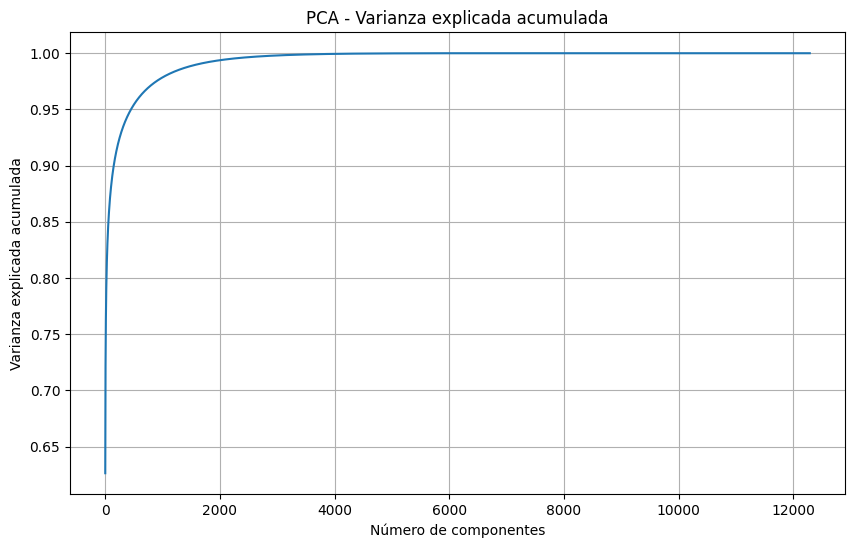

,umbral_varianza,porcentaje_varianza,componentes_necesarios,varianza_acumulada
0,0.80,80%,23,0.801680
1,0.85,85%,56,0.850159
2,0.90,90%,149,0.900021
3,0.95,95%,451,0.950072


In [5]:
def graficar_varianza_acumulada(pca):
    """
    Grafica la varianza explicada acumulada del PCA.
    """
    varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada)
    plt.xlabel("Número de componentes")
    plt.ylabel("Varianza explicada acumulada")
    plt.title("PCA - Varianza explicada acumulada")
    plt.grid(True)
    plt.show()

    return varianza_acumulada


def calcular_componentes_por_varianza(pca, umbrales=(0.80, 0.85, 0.90, 0.95)):
    """
    Calcula cuántos componentes principales se necesitan para alcanzar
    distintos umbrales de varianza explicada acumulada.
    """
    varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
    resultados = []

    for umbral in umbrales:
        m = np.argmax(varianza_acumulada >= umbral) + 1
        resultados.append({
            "umbral_varianza": umbral,
            "porcentaje_varianza": f"{umbral * 100:.0f}%",
            "componentes_necesarios": m,
            "varianza_acumulada": varianza_acumulada[m - 1]
        })

    return pd.DataFrame(resultados)


varianza_acumulada = graficar_varianza_acumulada(pca_inicial)
tabla_componentes = calcular_componentes_por_varianza(pca_inicial)

display(tabla_componentes)

## 6. Construcción del espacio reducido final

Con base en la tabla anterior, se selecciona un número de componentes `m`.

In [6]:
def aplicar_pca_con_m_componentes(X_scaled, m):
    """
    Aplica PCA con m componentes y devuelve el espacio reducido.
    """
    pca = PCA(n_components=m)
    X_reducido = pca.fit_transform(X_scaled)
    return X_reducido, pca

m = 149

X_reducido, pca_final = aplicar_pca_con_m_componentes(X_scaled, m)

print("Forma del espacio reducido:", X_reducido.shape)
print("Varianza acumulada retenida:", pca_final.explained_variance_ratio_.sum())

Forma del espacio reducido: (27000, 149)
Varianza acumulada retenida: 0.899886


## 7. Modelado de clustering con K-Means

Se evalúa K-Means para distintos valores de `k`. En este caso se usa el método del codo mediante SSE/inercia y, de manera más importante, el coeficiente de silueta.

In [7]:
def evaluar_kmeans(X, rango_k=range(2, 13), muestra_silueta=5000, random_state=RANDOM_STATE):
    """
    Evalúa K-Means para varios valores de k usando inercia y silueta.
    La silueta se calcula sobre una muestra para reducir costo computacional.
    """
    resultados = []

    for k in tqdm(rango_k, desc="Evaluando K-Means"):
        modelo = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=10
        )

        etiquetas = modelo.fit_predict(X)

        silueta = silhouette_score(
            X,
            etiquetas,
            sample_size=muestra_silueta,
            random_state=random_state
        )

        resultados.append({
            "k": k,
            "inercia_sse": modelo.inertia_,
            "silueta": silueta
        })

    return pd.DataFrame(resultados)


tabla_kmeans = evaluar_kmeans(
    X_reducido,
    rango_k=range(2, 13),
    muestra_silueta=10000
)

display(tabla_kmeans)

Evaluando K-Means: 100%|██████████| 11/11 [00:17<00:00,  1.60s/it]


,k,inercia_sse,silueta
0,2,161507328.0,0.403859
1,3,125495784.0,0.317157
2,4,111205120.0,0.244829
3,5,103859912.0,0.209535
4,6,99672576.0,0.168292
5,7,97141464.0,0.148661
6,8,95146808.0,0.145523
7,9,93428424.0,0.145800
8,10,92096744.0,0.116096
9,11,91047272.0,0.098249


## 8. Gráficos para selección de k

El método del codo muestra cómo disminuye la inercia al aumentar el número de clústeres. El coeficiente de silueta permite evaluar separación y cohesión de los grupos.

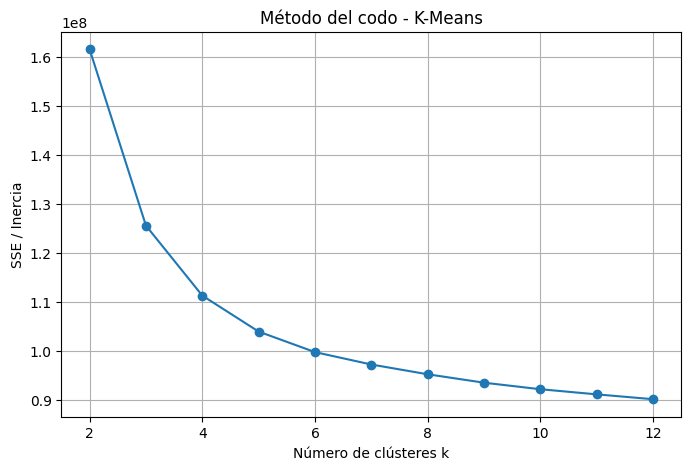

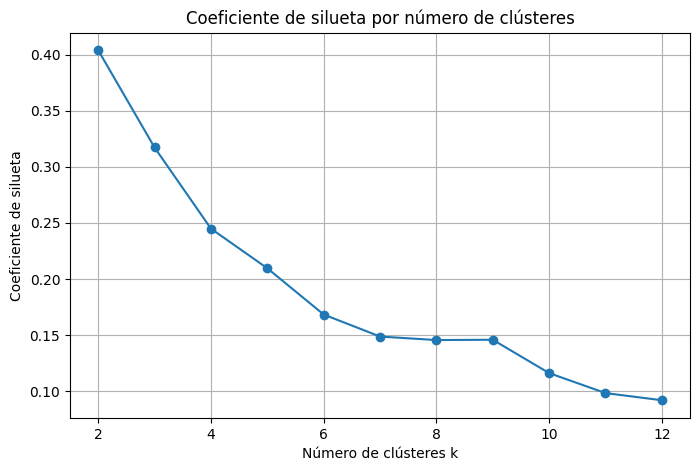

Mejor k según silueta: 2
Silueta máxima: 0.40385860204696655


In [8]:
def graficar_codo(tabla_kmeans):
    plt.figure(figsize=(8, 5))
    plt.plot(tabla_kmeans["k"], tabla_kmeans["inercia_sse"], marker="o")
    plt.xlabel("Número de clústeres k")
    plt.ylabel("SSE / Inercia")
    plt.title("Método del codo - K-Means")
    plt.grid(True)
    plt.show()


def graficar_silueta(tabla_kmeans):
    plt.figure(figsize=(8, 5))
    plt.plot(tabla_kmeans["k"], tabla_kmeans["silueta"], marker="o")
    plt.xlabel("Número de clústeres k")
    plt.ylabel("Coeficiente de silueta")
    plt.title("Coeficiente de silueta por número de clústeres")
    plt.grid(True)
    plt.show()


graficar_codo(tabla_kmeans)
graficar_silueta(tabla_kmeans)

mejor_fila = tabla_kmeans.loc[tabla_kmeans["silueta"].idxmax()]
k_optimo_silueta = int(mejor_fila["k"])

print("Mejor k según silueta:", k_optimo_silueta)
print("Silueta máxima:", mejor_fila["silueta"])

## 9. Ajuste final de K-Means

El modelo final de K-Means se ajusta con el valor de `k` que maximiza el coeficiente de silueta dentro del rango evaluado.

Si el análisis agroecológico requiriera una segmentación más granular, podría discutirse una solución alternativa, sin embargo, para esta entrega se prioriza el criterio cuantitativo solicitado.


In [9]:
def ajustar_kmeans_final(X, k, random_state=RANDOM_STATE):
    """
    Ajusta el modelo final de K-Means.
    """
    modelo = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )
    clusters = modelo.fit_predict(X)
    return clusters, modelo


k_final = k_optimo_silueta

clusters_kmeans, modelo_kmeans_final = ajustar_kmeans_final(X_reducido, k_final)

df_imagenes["cluster_kmeans"] = clusters_kmeans

print("k final seleccionado según silueta:", k_final)
display(df_imagenes["cluster_kmeans"].value_counts().sort_index())


k final seleccionado según silueta: 2


cluster_kmeans
0    16316
1    10684
Name: count, dtype: int64

## 10. Cruce preliminar con etiquetas reales y comparación entre k

Aunque las etiquetas reales no se usan para entrenar el clustering, se pueden cruzar con los clústeres obtenidos para interpretar qué tipo de cobertura terrestre predomina en cada grupo. Esta lectura no cambia la naturaleza no supervisada del análisis, pero ayuda a traducir los grupos geométricos del PCA a perfiles agroecológicos comprensibles.

Además de la solución final con `k = 2`, se revisan soluciones alternativas con `k = 3` y `k = 4`, porque el método del codo sugiere que podría existir una estructura algo más granular. Esta comparación se presenta como análisis de sensibilidad: la selección principal sigue siendo `k_final = k_optimo_silueta`.


In [10]:
def resumir_composicion_kmeans(df, columna_cluster, top_n=3):
    """Resume las clases reales predominantes por clúster."""
    conteos = pd.crosstab(df[columna_cluster], df["clase_real"])
    porcentajes = pd.crosstab(
        df[columna_cluster],
        df["clase_real"],
        normalize="index"
    ) * 100

    filas = []
    for cluster, fila in porcentajes.iterrows():
        top = fila.sort_values(ascending=False).head(top_n)
        composicion = ", ".join([
            f"{clase} ({porcentaje:.1f}%)"
            for clase, porcentaje in top.items()
            if porcentaje > 0
        ])
        filas.append({
            "cluster": cluster,
            "n_imagenes": int(conteos.loc[cluster].sum()),
            "clase_dominante": top.index[0],
            "pureza_aproximada_pct": top.iloc[0],
            "composicion_principal": composicion
        })

    return pd.DataFrame(filas)


ks_comparacion = [2, 3, 4]

tabla_comparacion_k = (
    tabla_kmeans[tabla_kmeans["k"].isin(ks_comparacion)]
    .loc[:, ["k", "inercia_sse", "silueta"]]
    .copy()
)

tabla_comparacion_k["reduccion_inercia_pct_vs_k_anterior"] = (
    tabla_comparacion_k["inercia_sse"].pct_change().abs() * 100
)

print("Comparación cuantitativa de K-Means para k = 2, 3 y 4:")
display(tabla_comparacion_k.round({
    "inercia_sse": 2,
    "silueta": 4,
    "reduccion_inercia_pct_vs_k_anterior": 2
}))

resumen_composicion_por_k = {}

for k in ks_comparacion:
    columna_cluster = f"cluster_kmeans_k{k}"

    if k == k_final:
        df_imagenes[columna_cluster] = clusters_kmeans
    else:
        etiquetas_k, _ = ajustar_kmeans_final(X_reducido, k)
        df_imagenes[columna_cluster] = etiquetas_k

    resumen_composicion_por_k[k] = resumir_composicion_kmeans(
        df_imagenes,
        columna_cluster=columna_cluster,
        top_n=3
    )

    print(f"Composición principal por clúster para k = {k}:")
    display(resumen_composicion_por_k[k].round(2))

tabla_cruce_kmeans_conteo = pd.crosstab(
    df_imagenes["cluster_kmeans"],
    df_imagenes["clase_real"]
)

tabla_cruce_kmeans_porcentaje = pd.crosstab(
    df_imagenes["cluster_kmeans"],
    df_imagenes["clase_real"],
    normalize="index"
) * 100

print("Conteos por cluster y clase real para la solución final k = 2:")
display(tabla_cruce_kmeans_conteo)

print("Porcentajes por cluster y clase real para la solución final k = 2:")
display(tabla_cruce_kmeans_porcentaje.round(2))


Comparación cuantitativa de K-Means para k = 2, 3 y 4:


,k,inercia_sse,silueta,reduccion_inercia_pct_vs_k_anterior
0,2,161507328.0,0.4039,NaN
1,3,125495784.0,0.3172,22.30
2,4,111205120.0,0.2448,11.39


Composición principal por clúster para k = 2:


,cluster,n_imagenes,clase_dominante,pureza_aproximada_pct,composicion_principal
0,0,16316,Forest,18.39,"Forest (18.4%), SeaLake (15.3%), River (13.4%)"
1,1,10684,Industrial,22.00,"Industrial (22.0%), AnnualCrop (20.9%), Perman..."


Composición principal por clúster para k = 3:


...

,cluster,n_imagenes,clase_dominante,pureza_aproximada_pct,composicion_principal
0,0,7629,Forest,38.67,"Forest (38.7%), SeaLake (26.5%), Pasture (10.9%)"
1,1,7396,Industrial,22.44,"Industrial (22.4%), AnnualCrop (17.8%), Perman..."
2,2,2791,AnnualCrop,30.60,"AnnualCrop (30.6%), Industrial (23.5%), Perman..."
3,3,9184,Residential,18.50,"Residential (18.5%), River (16.5%), Herbaceous..."


Conteos por cluster y clase real para la solución final k = 2:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_kmeans,,,,,,,,,,
0,763,3000,1874,1721,150,1675,799,1644,2191,2499
1,2237,0,1126,779,2350,325,1701,1356,309,501


Porcentajes por cluster y clase real para la solución final k = 2:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_kmeans,,,,,,,,,,
0,4.68,18.39,11.49,10.55,0.92,10.27,4.90,10.08,13.43,15.32
1,20.94,0.00,10.54,7.29,22.00,3.04,15.92,12.69,2.89,4.69


### Lectura de la comparación entre k

La silueta selecciona **k = 2**, indicando la separación más robusta en dos macrogrupos. Sin embargo, el método del codo sugiere una posible estructura más granular entre **k = 3** y **k = 4**, ya que la reducción de inercia aún puede aportar subgrupos interpretables. Para cumplir el criterio cuantitativo principal se usa **k = 2**, aunque las soluciones alternativas podrían explorarse si el objetivo fuera un perfilado agroecológico más detallado.

En términos de informe, esta decisión implica que el modelo final privilegia estabilidad y separación global sobre granularidad. Por eso los clústeres finales se interpretan como macroperfiles de cobertura, no como una clasificación fina de las 10 clases EuroSAT.


## 11. DBSCAN: selección de hiperparámetros y ajuste

DBSCAN es un método basado en densidad: no requiere fijar `k` y puede marcar observaciones como ruido (`cluster = -1`). En esta situación se usa como complemento de K-Means para revisar si existen imágenes atípicas asociadas con coberturas potencialmente problemáticas.

Como DBSCAN depende directamente de distancias, se estandariza el espacio PCA antes de aplicarlo. El modelo se ajusta sobre `X_reducido`, no sobre los píxeles originales, para mantener la coherencia con la reducción dimensional.


In [11]:
X_dbscan, _ = escalar_datos(X_reducido)

print("Forma de X_dbscan:", X_dbscan.shape)
print("Media aproximada:", np.round(X_dbscan.mean(), 4))
print("Desviación aproximada:", np.round(X_dbscan.std(), 4))


Forma de X_dbscan: (27000, 149)
Media aproximada: -0.0
Desviación aproximada: 1.0


### Selección de `eps` mediante k-distance

El parámetro más sensible de DBSCAN es `eps`, que define el radio de vecindad. Se toma como referencia la distancia al vecino número `min_samples` y se proponen tres candidatos de `eps` mediante cuantiles altos de esas distancias.


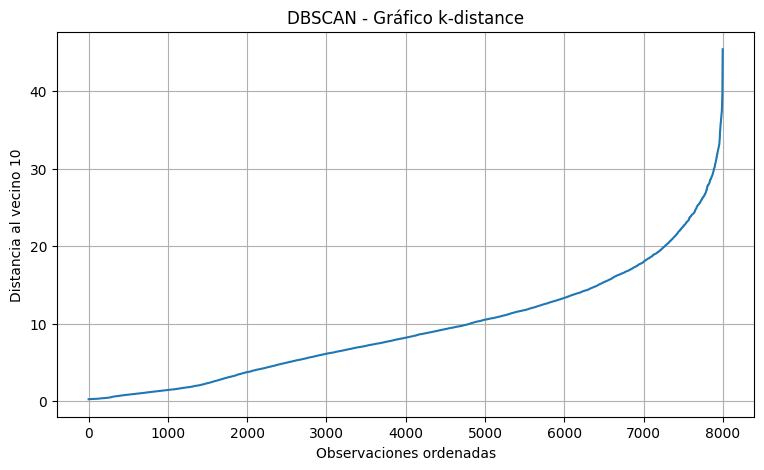

,cuantil,eps_candidato
0,0.85,16.807
1,0.90,19.352
2,0.95,23.920


In [12]:
def calcular_k_distancias(X, min_samples=10, muestra=8000, random_state=RANDOM_STATE):
    """
    Calcula las distancias al k-ésimo vecino más cercano.
    Si el dataset es grande, usa una muestra para reducir costo computacional.
    """
    rng = np.random.default_rng(random_state)

    if muestra is not None and X.shape[0] > muestra:
        indices = rng.choice(X.shape[0], size=muestra, replace=False)
        X_eval = X[indices]
    else:
        X_eval = X

    vecinos = NearestNeighbors(
        n_neighbors=min_samples,
        metric="euclidean",
        n_jobs=-1
    )
    vecinos.fit(X_eval)

    distancias, _ = vecinos.kneighbors(X_eval)
    k_distancias = np.sort(distancias[:, -1])

    return k_distancias


def graficar_k_distancias(k_distancias, min_samples):
    """
    Grafica las k-distancias ordenadas para apoyar la selección de eps.
    """
    plt.figure(figsize=(9, 5))
    plt.plot(k_distancias)
    plt.xlabel("Observaciones ordenadas")
    plt.ylabel(f"Distancia al vecino {min_samples}")
    plt.title("DBSCAN - Gráfico k-distance")
    plt.grid(True)
    plt.show()


def proponer_eps_por_cuantiles(k_distancias, cuantiles=(0.85, 0.90, 0.95)):
    """
    Propone valores de eps a partir de cuantiles de las k-distancias.
    """
    valores = np.quantile(k_distancias, cuantiles)

    return pd.DataFrame({
        "cuantil": cuantiles,
        "eps_candidato": valores
    })

k_distancias = calcular_k_distancias(
    X_dbscan,
    min_samples=10,
    muestra=8000
)

graficar_k_distancias(k_distancias, min_samples=10)

tabla_eps_candidatos = proponer_eps_por_cuantiles(k_distancias)
eps_candidatos = tabla_eps_candidatos["eps_candidato"].round(3).unique()

display(tabla_eps_candidatos.round(3))


### Evaluación compacta de hiperparámetros

Se evalúan combinaciones de `eps` y `min_samples` sobre una muestra reproducible del PCA estandarizado. Para cada combinación se reportan los elementos solicitados por la rúbrica: número de clústeres encontrados, porcentaje de ruido y tamaño relativo del clúster principal.


In [13]:
def resumir_etiquetas_dbscan(etiquetas):
    """
    Resume cantidad de clústeres y ruido en una solución DBSCAN.
    """
    etiquetas = np.asarray(etiquetas)
    mascara_ruido = etiquetas == -1
    clusters_validos = sorted(set(etiquetas) - {-1})
    conteos = pd.Series(etiquetas).value_counts().sort_index()

    if clusters_validos:
        mayor_cluster = int(conteos.loc[clusters_validos].max())
    else:
        mayor_cluster = 0

    return {
        "n_clusters": len(clusters_validos),
        "n_ruido": int(mascara_ruido.sum()),
        "pct_ruido": float(mascara_ruido.mean() * 100),
        "mayor_cluster": mayor_cluster,
        "pct_mayor_cluster": float(mayor_cluster / len(etiquetas) * 100)
    }


def obtener_muestra_dbscan(X, muestra=8000, random_state=42):
    """
    Obtiene una muestra reproducible para la evaluación de hiperparámetros.
    """
    if muestra is None or X.shape[0] <= muestra:
        return X

    rng = np.random.default_rng(random_state)
    indices = rng.choice(X.shape[0], size=muestra, replace=False)
    return X[indices]


def evaluar_dbscan(
    X,
    eps_values,
    min_samples_values=(10, 20),
    muestra_modelado=10000,
    random_state=RANDOM_STATE
):
    """
    Evalúa DBSCAN en una grilla compacta de eps y min_samples.
    La evaluación se hace sobre una muestra para reducir costo computacional.
    """
    X_eval = obtener_muestra_dbscan(
        X,
        muestra=muestra_modelado,
        random_state=random_state
    )

    resultados = []

    for min_samples in tqdm(min_samples_values, desc="Evaluando DBSCAN - min_samples"):
        for eps in eps_values:
            modelo = DBSCAN(
                eps=float(eps),
                min_samples=int(min_samples),
                metric="euclidean",
                n_jobs=-1
            )
            etiquetas = modelo.fit_predict(X_eval)

            resumen = resumir_etiquetas_dbscan(etiquetas)
            resumen.update({
                "eps": float(eps),
                "min_samples": int(min_samples),
                "n_eval": X_eval.shape[0]
            })
            resultados.append(resumen)

    columnas = [
        "eps", "min_samples", "n_eval", "n_clusters", "pct_ruido",
        "pct_mayor_cluster"
    ]

    return pd.DataFrame(resultados)[columnas]


tabla_dbscan = evaluar_dbscan(
    X_dbscan,
    eps_values=eps_candidatos,
    min_samples_values=(10, 20),
    muestra_modelado=10000
)

display(tabla_dbscan.round(3))


Evaluando DBSCAN - min_samples: 100%|██████████| 2/2 [00:04<00:00,  2.09s/it]


,eps,min_samples,n_eval,n_clusters,pct_ruido,pct_mayor_cluster
0,16.807,10,10000,1,13.53,86.47
1,19.352,10,10000,1,9.21,90.79
2,23.920,10,10000,1,4.39,95.61
3,16.807,20,10000,1,13.53,86.47
4,19.352,20,10000,1,9.21,90.79
5,23.920,20,10000,1,4.39,95.61


### Ajuste final de DBSCAN

La solución final se selecciona entre las combinaciones evaluadas. Se priorizan soluciones con al menos dos clústeres válidos y ruido controlado; si ninguna combinación produce múltiples clústeres, se conserva la alternativa con menor porcentaje de ruido para usar DBSCAN como detector de anomalías.

La columna `cluster_dbscan` identifica el resultado final; el valor `-1` representa imágenes clasificadas como ruido.


In [14]:
def seleccionar_solucion_dbscan(tabla_dbscan, max_pct_ruido=80):
    """
    Selecciona una solución DBSCAN razonable según la rúbrica.
    Prioriza múltiples clústeres con ruido controlado; si no existen,
    elige la solución con menor porcentaje de ruido.
    """
    candidatas = tabla_dbscan[
        (tabla_dbscan["n_clusters"] >= 2)
        & (tabla_dbscan["pct_ruido"] <= max_pct_ruido)
    ].copy()

    if candidatas.empty:
        candidatas = tabla_dbscan[tabla_dbscan["n_clusters"] >= 1].copy()

    if candidatas.empty:
        candidatas = tabla_dbscan.copy()

    seleccion = candidatas.sort_values(
        ["n_clusters", "pct_ruido", "pct_mayor_cluster"],
        ascending=[False, True, True]
    ).iloc[0]

    return seleccion


def ajustar_dbscan_final(X, eps, min_samples):
    """
    Ajusta DBSCAN final con los hiperparámetros seleccionados.
    """
    modelo = DBSCAN(
        eps=float(eps),
        min_samples=int(min_samples),
        metric="euclidean",
        n_jobs=-1
    )
    etiquetas = modelo.fit_predict(X)
    return etiquetas, modelo


solucion_dbscan = seleccionar_solucion_dbscan(tabla_dbscan, max_pct_ruido=80)

eps_final_dbscan = float(solucion_dbscan["eps"])
min_samples_final_dbscan = int(solucion_dbscan["min_samples"])

clusters_dbscan, modelo_dbscan_final = ajustar_dbscan_final(
    X_dbscan,
    eps=eps_final_dbscan,
    min_samples=min_samples_final_dbscan
)

df_imagenes["cluster_dbscan"] = clusters_dbscan

print("Parámetros seleccionados para DBSCAN:")
print("eps:", eps_final_dbscan)
print("min_samples:", min_samples_final_dbscan)
print("Resumen de la solución seleccionada:")
display(solucion_dbscan.to_frame().T.round(3))

conteo_dbscan = (
    df_imagenes["cluster_dbscan"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_dbscan")
    .reset_index(name="cantidad_imagenes")
)

display(conteo_dbscan)


Parámetros seleccionados para DBSCAN:
eps: 23.92
min_samples: 10
Resumen de la solución seleccionada:


,eps,min_samples,n_eval,n_clusters,pct_ruido,pct_mayor_cluster
2,23.92,10.0,10000.0,1.0,4.39,95.61


,cluster_dbscan,cantidad_imagenes
0,-1,1170
1,0,25830


### Lectura de DBSCAN

La elección de los hiperparámetros de DBSCAN se justificó a partir del gráfico k-distance y de una evaluación compacta de combinaciones. Para `eps` se tomaron tres candidatos derivados de cuantiles altos de las distancias al vecino número 10: **16.782**, **19.416** y **23.924**. Estos valores representan radios de vecindad progresivamente más permisivos. Para `min_samples` se evaluaron **10** y **20**, valores razonables para exigir una densidad mínima sin volver demasiado restrictiva la identificación de regiones densas en el espacio PCA.

La solución seleccionada fue **eps = 23.924** y **min_samples = 10**. Esta combinación produjo el menor porcentaje de ruido dentro de las alternativas evaluadas que conservaron un clúster denso. En la grilla evaluada, DBSCAN no encontró una partición granular de varias coberturas terrestres; concentró la mayoría de imágenes en un grupo principal y separó una fracción pequeña como ruido.

Al ajustar DBSCAN sobre las **27.000 imágenes**, el método encontró **1 clúster denso** y clasificó **1.183 imágenes como ruido** (`cluster = -1`). Esto equivale aproximadamente al **4.4%** del total, por lo que DBSCAN **no identifica muchas imágenes como anomalías**. Más bien, concentra la gran mayoría de las imágenes en un único grupo (**25.817 imágenes - 95.6%**) y separa un conjunto pequeño de observaciones atípicas. Esta estructura sugiere que, con la representación PCA utilizada, DBSCAN funciona más como detector de imágenes atípicas que como segmentador de múltiples coberturas terrestres.


## 12. Validación interna

La validación interna solicitada por la rúbrica se reporta mediante el **coeficiente de silueta del mejor modelo de clustering**. En este notebook, el modelo principal es K-Means, porque fue el algoritmo que produjo una partición interpretable con `k` clústeres.

Para DBSCAN se reportan como apoyo el número de clústeres válidos y el porcentaje de ruido, que son los criterios directamente solicitados para este algoritmo.


In [15]:
def calcular_silueta_modelo(
    X,
    etiquetas,
    muestra_silueta=5000,
    random_state=42
):
    """Calcula el coeficiente de silueta para un conjunto de etiquetas."""
    etiquetas = np.asarray(etiquetas)

    if len(set(etiquetas)) < 2:
        return np.nan

    sample_size = min(muestra_silueta, X.shape[0])

    return silhouette_score(
        X,
        etiquetas,
        sample_size=sample_size,
        random_state=random_state
    )


def construir_validacion_interna(
    X_kmeans,
    etiquetas_kmeans,
    etiquetas_dbscan,
    muestra_silueta=5000,
    random_state=RANDOM_STATE
):
    """Construye una tabla de validación interna enfocada en el modelo principal."""
    resumen_dbscan = resumir_etiquetas_dbscan(etiquetas_dbscan)

    filas = [
        {
            "modelo": "K-Means",
            "n_clusters_validos": len(set(etiquetas_kmeans)),
            "pct_ruido": 0.0,
            "silueta": calcular_silueta_modelo(
                X_kmeans,
                etiquetas_kmeans,
                muestra_silueta=muestra_silueta,
                random_state=random_state
            ),
            "comentario": "Modelo principal seleccionado por validación interna."
        },
        {
            "modelo": "DBSCAN",
            "n_clusters_validos": resumen_dbscan["n_clusters"],
            "pct_ruido": resumen_dbscan["pct_ruido"],
            "silueta": np.nan,
            "comentario": "Se reporta número de clústeres y ruido; no se usa como modelo principal."
        }
    ]

    return pd.DataFrame(filas)


tabla_validacion_interna = construir_validacion_interna(
    X_kmeans=X_reducido,
    etiquetas_kmeans=clusters_kmeans,
    etiquetas_dbscan=clusters_dbscan,
    muestra_silueta=5000
)

display(tabla_validacion_interna.round(4))

modelos_con_silueta = tabla_validacion_interna.dropna(subset=["silueta"])

if modelos_con_silueta.empty:
    modelo_mejor_interno = None
    print("No hay modelos con silueta interpretable.")
else:
    fila_mejor_interno = modelos_con_silueta.loc[modelos_con_silueta["silueta"].idxmax()]
    modelo_mejor_interno = fila_mejor_interno["modelo"]
    print("Mejor modelo según validación interna:", modelo_mejor_interno)
    print("Silueta del mejor modelo:", round(fila_mejor_interno["silueta"], 4))


,modelo,n_clusters_validos,pct_ruido,silueta,comentario
0,K-Means,2,0.0000,0.4044,Modelo principal seleccionado por validación i...
1,DBSCAN,1,4.3333,NaN,Se reporta número de clústeres y ruido; no se ...


Mejor modelo según validación interna: K-Means
Silueta del mejor modelo: 0.4044


### Interpretación de la validación interna

La validación interna favorece a **K-Means**, con una silueta de **0.4044** para la solución de **k = 2**. Este valor indica una separación moderada en el espacio PCA reducido: no es una segmentación perfecta, pero sí ofrece una partición geométricamente más interpretable bajo el criterio solicitado.

DBSCAN produjo un único clúster válido y un grupo pequeño de ruido. En consecuencia, no compite como modelo principal de segmentación, sino que se interpreta como un detector de observaciones atípicas. Para el resto del análisis, **K-Means se conserva como modelo principal de clustering** y DBSCAN como apoyo para anomalías.


## 13. Validación externa con etiquetas reales

Las etiquetas reales de EuroSAT se usan únicamente para validar e interpretar los clústeres; no participaron en el ajuste de K-Means ni de DBSCAN.

Se reportan dos métricas de validación externa:

- **Adjusted Rand Index (ARI):** mide acuerdo entre clústeres y clases reales corrigiendo por azar.
- **Normalized Mutual Information (NMI):** mide cuánta información comparten las etiquetas reales y los clústeres.

Para DBSCAN se conserva la lectura con ruido incluido y excluido, separando su bajo valor como segmentador general de su utilidad como detector de anomalías.


In [16]:
def calcular_metricas_validacion_externa(y_real, etiquetas_cluster):
    """
    Calcula ARI y NMI entre etiquetas reales y etiquetas de clustering.
    """
    return {
        "ARI": adjusted_rand_score(y_real, etiquetas_cluster),
        "NMI": normalized_mutual_info_score(y_real, etiquetas_cluster)
    }


def evaluar_validacion_externa(
    df,
    columna_real="clase_real",
    columnas_cluster=("cluster_kmeans", "cluster_dbscan")
):
    """
    Construye una tabla de validación externa para los modelos disponibles.
    """
    filas = []
    y_real = df[columna_real].values

    for columna in columnas_cluster:
        if columna not in df.columns:
            continue

        etiquetas = df[columna].values
        metricas = calcular_metricas_validacion_externa(y_real, etiquetas)

        filas.append({
            "modelo": columna.replace("cluster_", "").upper(),
            "tratamiento_ruido": "incluido" if -1 in set(etiquetas) else "no aplica",
            "n_imagenes": len(etiquetas),
            "n_clusters": len(set(etiquetas) - {-1}),
            "pct_ruido": float((etiquetas == -1).mean() * 100) if -1 in set(etiquetas) else 0.0,
            **metricas
        })

        if -1 in set(etiquetas):
            mascara = etiquetas != -1
            metricas_sin_ruido = calcular_metricas_validacion_externa(
                y_real[mascara],
                etiquetas[mascara]
            )
            filas.append({
                "modelo": columna.replace("cluster_", "").upper(),
                "tratamiento_ruido": "excluido",
                "n_imagenes": int(mascara.sum()),
                "n_clusters": len(set(etiquetas[mascara])),
                "pct_ruido": 0.0,
                **metricas_sin_ruido
            })

    return pd.DataFrame(filas)


tabla_validacion_externa = evaluar_validacion_externa(df_imagenes)

display(tabla_validacion_externa.round(3))

fila_mejor_externo = tabla_validacion_externa.loc[
    tabla_validacion_externa["NMI"].idxmax()
]

modelo_mejor_externo = fila_mejor_externo["modelo"]

print("Mejor modelo según NMI externo:", modelo_mejor_externo)
print("ARI:", round(fila_mejor_externo["ARI"], 3))
print("NMI:", round(fila_mejor_externo["NMI"], 3))


,modelo,tratamiento_ruido,n_imagenes,n_clusters,pct_ruido,ARI,NMI
0,KMEANS,no aplica,27000,2,0.000,0.065,0.138
1,DBSCAN,incluido,27000,1,4.333,0.009,0.079
2,DBSCAN,excluido,25830,1,0.000,0.000,0.000


Mejor modelo según NMI externo: KMEANS
ARI: 0.065
NMI: 0.138


### Interpretación de la validación externa

La validación externa muestra una correspondencia limitada entre los clústeres no supervisados y las 10 clases reales de EuroSAT. K-Means obtiene **ARI = 0.065** y **NMI = 0.138**, valores bajos pero superiores a DBSCAN. Esto indica que la partición de K-Means no reproduce directamente las clases originales, sino que agrupa las imágenes en macroestructuras más generales.

DBSCAN presenta menor correspondencia externa: con ruido incluido obtiene **ARI = 0.009** y **NMI = 0.080**, y al excluir ruido queda sin segmentación útil porque solo conserva un clúster. Por tanto, la validación externa refuerza la decisión de usar K-Means para perfilado general y DBSCAN solo como señal complementaria de anomalías.

La matriz de confusión es necesaria para interpretar estos valores: ARI y NMI resumen la composición general, pero no muestran qué clases reales componen cada clúster.


## 14. Matriz de cruce y perfilado agroecológico

La matriz de cruce entre clústeres y clases reales se usa solo para interpretar la segmentación no supervisada. La rúbrica pide inspeccionar qué clases componen cada clúster, identificar posibles zonas dañadas o en estrés y revisar si el algoritmo separa cultivos de bosques.

Para el perfilado se agrupan las clases reales en familias interpretables:

- **Cultivos y pastos:** `AnnualCrop`, `PermanentCrop`, `Pasture`.
- **Vegetación natural:** `Forest`, `HerbaceousVegetation`.
- **Agua:** `SeaLake`, `River`.
- **Urbano:** `Industrial`, `Residential`, `Highway`.
- **Posible estrés o daño agroecológico:** `Industrial`, `Residential`, `SeaLake`, `River`.


Matriz de cruce K-Means - conteos:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_kmeans,,,,,,,,,,
0,763,3000,1874,1721,150,1675,799,1644,2191,2499
1,2237,0,1126,779,2350,325,1701,1356,309,501


Matriz de cruce K-Means - porcentajes por clúster:


clase_real,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
cluster_kmeans,,,,,,,,,,
0,4.68,18.39,11.49,10.55,0.92,10.27,4.90,10.08,13.43,15.32
1,20.94,0.00,10.54,7.29,22.00,3.04,15.92,12.69,2.89,4.69


Composición principal por clúster K-Means:


,cluster,clase_dominante,pureza_aproximada_pct,composicion_principal
0,0,Forest,18.39,"Forest (18.4%), SeaLake (15.3%), River (13.4%)"
1,1,Industrial,22.00,"Industrial (22.0%), AnnualCrop (20.9%), Perman..."


Perfil agroecológico por clúster K-Means:


,cluster,clase_dominante,pct_clase_dominante,pct_cultivos_pasturas,pct_vegetacion_natural,pct_agua,pct_urbano_infraestructura,pct_revision_agroecologica,interpretacion_agroecologica
0,0,Forest,18.39,19.84,29.87,28.74,21.54,39.74,"Perfil natural-hídrico, revisar si el evento f..."
1,1,Industrial,22.00,39.90,10.54,7.58,41.98,42.27,"Perfil intervenido/industrial, prioridad de re..."


Clústeres candidatos a revisión agroecológica:


,cluster,pct_revision_agroecologica,pct_agua,pct_urbano_infraestructura,interpretacion_agroecologica
0,0,39.74,28.74,21.54,"Perfil natural-hídrico, revisar si el evento f..."
1,1,42.27,7.58,41.98,"Perfil intervenido/industrial, prioridad de re..."


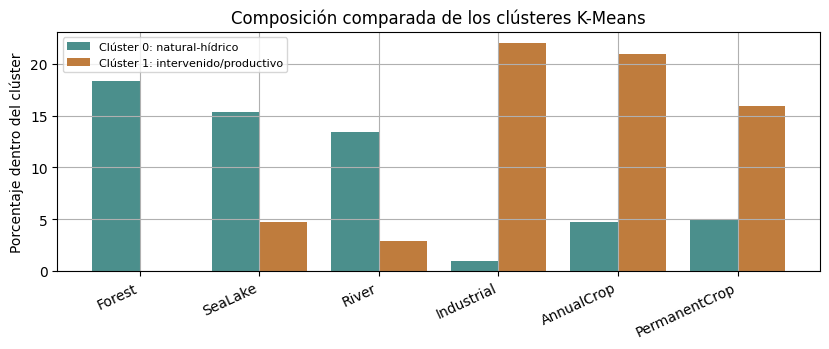

In [17]:
def construir_matriz_confusion_clusters(
    df,
    columna_cluster,
    columna_real="clase_real",
    normalizar=False
):
    """
    Construye una matriz de cruce entre clústeres y clases reales.
    Si normalizar=True, devuelve porcentajes por fila.
    """
    if normalizar:
        return pd.crosstab(
            df[columna_cluster],
            df[columna_real],
            normalize="index"
        ) * 100

    return pd.crosstab(df[columna_cluster], df[columna_real])


def resumir_composicion_clusters(tabla_porcentaje, top_n=3):
    """Resume las clases reales predominantes dentro de cada clúster."""
    filas = []

    for cluster, fila in tabla_porcentaje.iterrows():
        top = fila.sort_values(ascending=False).head(top_n)
        composicion = ", ".join([
            f"{clase} ({porcentaje:.1f}%)"
            for clase, porcentaje in top.items()
            if porcentaje > 0
        ])

        filas.append({
            "cluster": cluster,
            "clase_dominante": top.index[0],
            "pureza_aproximada_pct": top.iloc[0],
            "composicion_principal": composicion
        })

    return pd.DataFrame(filas)


def construir_perfil_agroecologico(
    matriz_porcentaje,
    clases_cultivo=("AnnualCrop", "PermanentCrop", "Pasture"),
    clases_vegetacion=("Forest", "HerbaceousVegetation"),
    clases_agua=("SeaLake", "River"),
    clases_urbano=("Industrial", "Residential", "Highway"),
    clases_revision=("Industrial", "Residential", "SeaLake", "River")
):
    """Construye un perfil agroecológico por clúster."""
    def sumar_clases(fila, clases):
        return sum(fila.get(clase, 0) for clase in clases)

    filas = []

    for cluster, fila in matriz_porcentaje.iterrows():
        composicion = fila.sort_values(ascending=False)
        clase_dominante = composicion.index[0]
        porcentaje_dominante = composicion.iloc[0]

        pct_cultivos = sumar_clases(fila, clases_cultivo)
        pct_vegetacion = sumar_clases(fila, clases_vegetacion)
        pct_agua = sumar_clases(fila, clases_agua)
        pct_urbano = sumar_clases(fila, clases_urbano)
        pct_revision = sumar_clases(fila, clases_revision)
        pct_industrial = fila.get("Industrial", 0)

        if pct_industrial >= 15 or pct_urbano >= 35:
            interpretacion = "Perfil intervenido/industrial, prioridad de revisión"
        elif pct_agua >= 25 and pct_vegetacion >= 25:
            interpretacion = "Perfil natural-hídrico, revisar si el evento fue inundación"
        elif pct_cultivos >= 40:
            interpretacion = "Perfil agrícola predominante"
        elif pct_vegetacion >= 40:
            interpretacion = "Perfil de vegetación/bosque predominante"
        elif pct_revision >= 35:
            interpretacion = "Perfil mixto con señal de revisión agroecológica"
        else:
            interpretacion = "Perfil mixto"

        filas.append({
            "cluster": cluster,
            "clase_dominante": clase_dominante,
            "pct_clase_dominante": porcentaje_dominante,
            "pct_cultivos_pasturas": pct_cultivos,
            "pct_vegetacion_natural": pct_vegetacion,
            "pct_agua": pct_agua,
            "pct_urbano_infraestructura": pct_urbano,
            "pct_revision_agroecologica": pct_revision,
            "interpretacion_agroecologica": interpretacion
        })

    return pd.DataFrame(filas)



def graficar_composicion_kmeans(
    matriz_porcentaje,
    clases_mostrar=(
        "Forest", "SeaLake", "River", "Industrial", "AnnualCrop", "PermanentCrop"
    ),
    etiquetas_perfil=None,
    colores=("#4b8f8c", "#bf7c3d")
):
    """Grafica la composición porcentual de clases seleccionadas por clúster."""
    datos = matriz_porcentaje.reindex(columns=clases_mostrar, fill_value=0)
    clusters = list(datos.index)

    if etiquetas_perfil is None:
        etiquetas_perfil = {cluster: f"Clúster {cluster}" for cluster in clusters}

    x = np.arange(len(clases_mostrar))
    width = 0.8 / len(clusters)

    plt.figure(figsize=(8.4, 3.6))

    for i, cluster in enumerate(clusters):
        desplazamiento = (i - (len(clusters) - 1) / 2) * width
        etiqueta = etiquetas_perfil.get(cluster, f"Clúster {cluster}")
        color = colores[i % len(colores)]
        plt.bar(x + desplazamiento, datos.loc[cluster], width, label=etiqueta, color=color)

    plt.ylabel("Porcentaje dentro del clúster")
    plt.xticks(x, clases_mostrar, rotation=25, ha="right")
    plt.title("Composición comparada de los clústeres K-Means")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


matriz_confusion_kmeans_conteo = construir_matriz_confusion_clusters(
    df_imagenes,
    columna_cluster="cluster_kmeans",
    normalizar=False
)

matriz_confusion_kmeans_porcentaje = construir_matriz_confusion_clusters(
    df_imagenes,
    columna_cluster="cluster_kmeans",
    normalizar=True
)

resumen_composicion_kmeans = resumir_composicion_clusters(
    matriz_confusion_kmeans_porcentaje,
    top_n=3
)

perfil_agroecologico_kmeans = construir_perfil_agroecologico(
    matriz_confusion_kmeans_porcentaje
)

clusters_revision_kmeans = perfil_agroecologico_kmeans[
    perfil_agroecologico_kmeans["pct_revision_agroecologica"] >= 35
].copy()

print("Matriz de cruce K-Means - conteos:")
display(matriz_confusion_kmeans_conteo)

print("Matriz de cruce K-Means - porcentajes por clúster:")
display(matriz_confusion_kmeans_porcentaje.round(2))

print("Composición principal por clúster K-Means:")
display(resumen_composicion_kmeans.round(2))

print("Perfil agroecológico por clúster K-Means:")
display(perfil_agroecologico_kmeans.round(2))

print("Clústeres candidatos a revisión agroecológica:")
display(
    clusters_revision_kmeans[[
        "cluster", "pct_revision_agroecologica", "pct_agua",
        "pct_urbano_infraestructura", "interpretacion_agroecologica"
    ]].round(2)
)


etiquetas_perfil_kmeans = {
    0: "Clúster 0: natural-hídrico",
    1: "Clúster 1: intervenido/productivo"
}

graficar_composicion_kmeans(
    matriz_confusion_kmeans_porcentaje,
    etiquetas_perfil=etiquetas_perfil_kmeans
)


### Lectura de la matriz y perfiles

K-Means con **k = 2** no separa las 10 clases de EuroSAT, sino dos macrogrupos. En la ejecución resumida, el **clúster 0** está compuesto principalmente por **Forest (18.4%)**, **SeaLake (15.3%)** y **River (13.4%)**, por lo que se interpreta como un perfil más natural-hídrico. Este grupo no debe marcarse automáticamente como zona dañada, salvo que el evento evaluado sugiera inundación, expansión anómala de agua o cambios bruscos en cuerpos hídricos.

El **clúster 1** está compuesto principalmente por **Industrial (22.0%)**, **AnnualCrop (20.9%)** y **PermanentCrop (15.9%)**. Este perfil es más intervenido/productivo y constituye el principal candidato para revisión agroecológica por su mayor presencia de infraestructura e intervención antrópica.

La separación cultivos vs. bosques es parcial. `Forest` queda concentrado en el clúster natural-hídrico, mientras que `AnnualCrop` y `PermanentCrop` se concentran principalmente en el clúster intervenido/productivo. Sin embargo, la pureza de ambos clústeres es baja, por lo que la solución debe leerse como una priorización por macrozonas y no como clasificación fina de cobertura terrestre.


## 15. Perfilado de anomalías detectadas por DBSCAN

Aunque DBSCAN no generó múltiples clústeres de cobertura, sí identificó un conjunto pequeño de imágenes como ruido. Por eso se perfila únicamente la composición del grupo `cluster = -1`, que es la salida más útil de DBSCAN para la conexión agroecológica.


Composición de las imágenes clasificadas como ruido por DBSCAN:


,clase_real,cantidad_ruido,porcentaje_dentro_ruido
0,Industrial,1092,93.33
1,HerbaceousVegetation,29,2.48
2,PermanentCrop,19,1.62
3,Highway,12,1.03
4,AnnualCrop,11,0.94
5,River,6,0.51
6,Residential,1,0.09


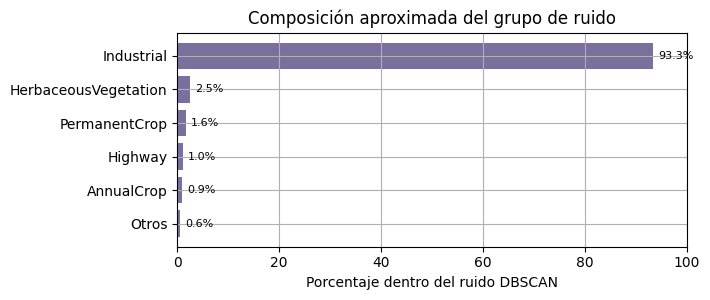

In [18]:
def perfilar_ruido_dbscan(df, columna_cluster="cluster_dbscan", columna_real="clase_real"):
    """Resume la composición de las imágenes marcadas como ruido por DBSCAN."""
    tabla_conteo = construir_matriz_confusion_clusters(
        df,
        columna_cluster=columna_cluster,
        columna_real=columna_real,
        normalizar=False
    )
    tabla_porcentaje = construir_matriz_confusion_clusters(
        df,
        columna_cluster=columna_cluster,
        columna_real=columna_real,
        normalizar=True
    )

    if -1 not in tabla_porcentaje.index:
        return pd.DataFrame(), tabla_conteo, tabla_porcentaje

    porcentajes = tabla_porcentaje.loc[-1].sort_values(ascending=False)
    conteos = tabla_conteo.loc[-1]

    filas = []
    for clase, porcentaje in porcentajes.items():
        if conteos[clase] > 0:
            filas.append({
                "clase_real": clase,
                "cantidad_ruido": int(conteos[clase]),
                "porcentaje_dentro_ruido": porcentaje
            })

    return pd.DataFrame(filas), tabla_conteo, tabla_porcentaje


perfil_ruido_dbscan, tabla_cruce_dbscan_conteo, tabla_cruce_dbscan_porcentaje = (
    perfilar_ruido_dbscan(df_imagenes)
)


def graficar_ruido_dbscan(perfil_ruido, top_n=5, color="#7b6f9e"):
    """Grafica la composición porcentual de las imágenes marcadas como ruido."""
    if perfil_ruido.empty:
        print("DBSCAN no identificó observaciones como ruido.")
        return

    datos = perfil_ruido.head(top_n).copy()
    porcentaje_otros = 100 - datos["porcentaje_dentro_ruido"].sum()

    if porcentaje_otros > 0:
        datos = pd.concat([
            datos,
            pd.DataFrame({
                "clase_real": ["Otros"],
                "cantidad_ruido": [np.nan],
                "porcentaje_dentro_ruido": [porcentaje_otros]
            })
        ], ignore_index=True)

    datos = datos.iloc[::-1]

    plt.figure(figsize=(7.2, 3.1))
    plt.barh(datos["clase_real"], datos["porcentaje_dentro_ruido"], color=color)
    plt.xlabel("Porcentaje dentro del ruido DBSCAN")
    plt.title("Composición aproximada del grupo de ruido")
    plt.xlim(0, 100)

    for i, valor in enumerate(datos["porcentaje_dentro_ruido"]):
        plt.text(valor + 1, i, f"{valor:.1f}%", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


print("Composición de las imágenes clasificadas como ruido por DBSCAN:")
display(perfil_ruido_dbscan.round(2))


graficar_ruido_dbscan(perfil_ruido_dbscan)


### Lectura agroecológica de DBSCAN

DBSCAN clasificó una fracción baja de imágenes como ruido, alrededor de **4.4%** del total. Ese grupo está fuertemente dominado por la clase **Industrial**. Por tanto, DBSCAN no funcionó como segmentador de múltiples coberturas, pero sí aportó una señal útil para detectar escenas atípicas asociadas a zonas industriales.

Desde la perspectiva de gestión agrícola, estas anomalías pueden priorizarse para revisión porque representan áreas intervenidas o potencialmente incompatibles con cobertura agroecológica saludable. Sin embargo, como DBSCAN concentró casi todas las demás imágenes en un solo clúster, K-Means sigue siendo el modelo principal para el perfilado general de coberturas.


## 16. Conclusión final

El análisis permitió construir una segmentación no supervisada de las imágenes EuroSAT a partir de un espacio reducido por PCA. Las etiquetas reales se usaron únicamente para validar e interpretar los resultados, no para entrenar los modelos.

La silueta selecciona **k = 2**, indicando la separación más robusta en dos macrogrupos. Sin embargo, el método del codo sugiere una posible estructura más granular entre **k = 3** y **k = 4**. Para cumplir el criterio cuantitativo principal se usa **k = 2**, aunque soluciones alternativas podrían explorarse para un perfilado agroecológico más detallado.

Con **K-Means (k = 2)** se obtuvo una separación moderada entre un perfil **natural-hídrico** y un perfil **intervenido/productivo**. El clúster natural-hídrico concentra mayor presencia relativa de **Forest**, **SeaLake** y **River**, mientras que el clúster intervenido/productivo agrupa principalmente **Industrial**, **AnnualCrop**, **PermanentCrop** y **Residential**. Por tanto, el segundo grupo es el principal candidato para revisión agroecológica, especialmente por su mayor componente urbano-industrial.

La validación externa mostró una correspondencia limitada con las 10 clases reales de EuroSAT (**ARI = 0.065**, **NMI = 0.138** para K-Means). Esto indica que el clustering no reproduce clases supervisadas finas, sino macroestructuras de similitud visual en el espacio PCA.

DBSCAN no generó múltiples clústeres interpretables: encontró un único clúster denso y una fracción baja de ruido. Su aporte principal fue complementar el análisis al identificar imágenes atípicas, dominadas por escenas **Industrial**, que podrían priorizarse para inspección humana o revisión geoespacial.

En conjunto, el procedimiento es útil como herramienta inicial de tamizaje después de un evento climático extremo. Permite separar parcialmente **cultivos/intervención** frente a **bosques/agua**, pero sus resultados deben interpretarse como apoyo para priorización y no como diagnóstico definitivo de daño agroecológico.
